In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [4]:
# DC Motor State Space Model
# States:  x = [i, omega, theta] 
# Input:   u = U (voltage)
# Output:  y = theta

A = np.array([[-R/L,   -Ke/L,  0],
              [ Kt/J,  -B/J,   0],   # 
              [ 0,      1,     0]])  # theta' = omega

B = np.array([[1/L],
              [0  ],
              [0  ]])

C = np.array([[0, 0, 1]])  # output is theta

D = np.array([[0]])

motor_ss = ss(A, B, C, D)
print(motor_ss)

<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[-4.e+03 -2.e+02  0.e+00]
     [ 1.e+01 -1.e-01  0.e+00]
     [ 0.e+00  1.e+00  0.e+00]]

B = [[2000.]
     [   0.]
     [   0.]]

C = [[0. 0. 1.]]

D = [[0.]]


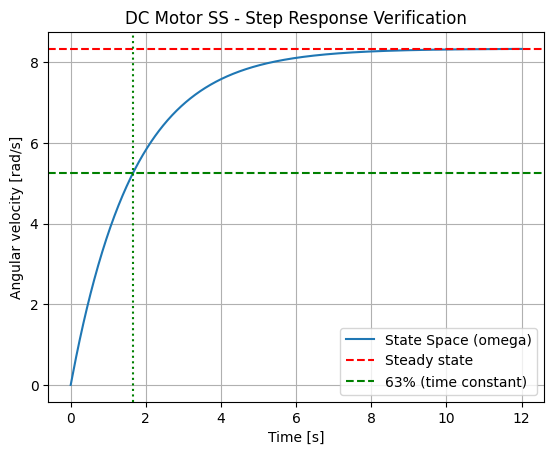

In [16]:
# Verify - compare with TF model
# Temporarily output omega (x2) instead of theta
C_omega = np.array([[0, 1, 0]])
motor_ss_omega = ss(A, B, C_omega, D)

K_static = 8.333
tau = 1.667

t, y = step_response(motor_ss_omega, T=np.linspace(0, 12, 1000))

plt.plot(t, y, label='State Space (omega)')
plt.axhline(y=K_static, color='r', linestyle='--', label='Steady state')
plt.axhline(y=0.63*K_static, color='g', linestyle='--', label='63% (time constant)')
plt.axvline(x=tau, color='g', linestyle=':')
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('DC Motor SS - Step Response Verification')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Controllability and Observability check
Co = ctrb(A, B)
Ob = obsv(A, C)

print(f'Controllability matrix rank: {np.linalg.matrix_rank(Co)}')
print(f'Observability matrix rank: {np.linalg.matrix_rank(Ob)}')
print(f'System order: {A.shape[0]}')
print()
if np.linalg.matrix_rank(Co) == A.shape[0]:
    print('System is CONTROLLABLE')
else:
    print('System is NOT controllable')
    
if np.linalg.matrix_rank(Ob) == A.shape[0]:
    print('System is OBSERVABLE')
else:
    print('System is NOT observable')

Controllability matrix rank: 3
Observability matrix rank: 3
System order: 3

System is CONTROLLABLE
System is OBSERVABLE
